In [20]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec('polars') is None:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'polars'])

import polars as pl
from pathlib import Path

In [21]:
day = '2024-03-01'
base_path = Path('.')
day_path = base_path / 'user_actions' / 'user_actions_3_months' / f'date={day}'

print(day_path)
parts = []
for parquet_file in day_path.glob('action_type=*/*.parquet'):
    part = pl.read_parquet(parquet_file).with_columns(
        pl.lit(parquet_file.parent.name.replace('action_type=', '')).alias('action_type_folder')
    )
    parts.append(part)

s = pl.concat(parts)
display(s.head())
print(s.shape)

user_actions/user_actions_3_months/date=2024-03-01


user_id,date,timestamp,action_type,widget_name,search_query,item_id,action_type_folder
i32,date,datetime[ns],str,str,str,i32,str
477044,2024-03-01,2024-03-01 14:07:33,"""search""","""search_suggestions""","""листья виноградные""",null,"""search"""
1149437,2024-03-01,2024-03-01 10:15:29,"""search""","""search_suggestions""","""barilla""",null,"""search"""
8691649,2024-03-01,2024-03-01 09:42:11,"""search""","""mobile_search_bar""","""гранола""",null,"""search"""
7404264,2024-03-01,2024-03-01 06:54:24,"""search""","""search_suggestions""","""зубная паста парадонтакс""",null,"""search"""
2063481,2024-03-01,2024-03-01 05:41:21,"""search""","""search_suggestions""","""ясно солнышко 2""",null,"""search"""


(10446059, 8)


In [22]:
s = s.filter(pl.col('user_id') != 6195822)

In [23]:
s.filter(pl.col('user_id') == 3945998).sort('timestamp').head(10)

user_id,date,timestamp,action_type,widget_name,search_query,item_id,action_type_folder
i32,date,datetime[ns],str,str,str,i32,str
3945998,2024-03-01,2024-03-01 07:58:42,"""search""","""search_suggestions""","""супрадин кидс""",null,"""search"""
3945998,2024-03-01,2024-03-01 07:58:42,"""view""","""search_catalog_listing""","""супрадин кидс""",233485,"""view"""
3945998,2024-03-01,2024-03-01 07:58:42,"""view""","""search_catalog_listing""","""супрадин кидс""",204596,"""view"""
3945998,2024-03-01,2024-03-01 07:58:42,"""view""","""search_catalog_listing""","""супрадин кидс""",149306,"""view"""
3945998,2024-03-01,2024-03-01 07:58:42,"""view""","""search_catalog_listing""","""супрадин кидс""",9669,"""view"""
3945998,2024-03-01,2024-03-01 07:58:52,"""click""","""search_catalog_listing""","""супрадин кидс""",233485,"""click"""
3945998,2024-03-01,2024-03-01 07:59:00,"""click""","""search_catalog_listing""","""супрадин кидс""",9669,"""click"""
3945998,2024-03-01,2024-03-01 07:59:07,"""click""","""search_catalog_listing""","""супрадин кидс""",233485,"""click"""
3945998,2024-03-01,2024-03-01 07:59:26,"""to_cart""","""search_catalog_listing""","""супрадин кидс""",9669,"""to_cart"""


Analasy bot

In [24]:
bot = s.filter(pl.col('user_id') == 6195822)

In [25]:
bot.select(pl.all().drop_nulls().n_unique())

user_id,date,timestamp,action_type,widget_name,search_query,item_id,action_type_folder
u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0


In [26]:
bot.get_column('action_type').drop_nulls().value_counts(sort=True)

action_type,count
str,u32


дальше...

In [ ]:
payment_actions = ['favorite', 'to_cart']

events_by_ts = (
    s.select(['user_id', 'timestamp', 'action_type'])
    .group_by(['user_id', 'timestamp'])
    .agg(
        (pl.col('action_type') == 'search').sum().cast(pl.UInt32).alias('search_at_ts'),
        (pl.col('action_type') == 'view').sum().cast(pl.UInt32).alias('view_at_ts'),
        pl.col('action_type').filter(pl.col('action_type').is_in(payment_actions)).alias('payment_action'),
    )
    .sort(['user_id', 'timestamp'])
)

events_by_ts.head()

user_id,timestamp,search_at_ts,view_at_ts,payment_action
i32,datetime[ns],u32,u32,list[str]
78,2024-03-01 15:57:19,1,0,[]
78,2024-03-01 15:57:20,0,4,[]
78,2024-03-01 15:57:25,0,0,[]
78,2024-03-01 15:57:33,0,2,[]
78,2024-03-01 15:57:34,0,4,[]


In [ ]:
events_after_first_search = (
    events_by_ts
    .with_columns(
        (pl.col('search_at_ts').cum_sum().over('user_id') > 0).alias('after_first_search')
    )
    .filter(pl.col('after_first_search'))
    .with_columns(
        pl.col('search_at_ts').cum_sum().over('user_id').alias('search_count'),
        pl.col('view_at_ts').cum_sum().over('user_id').alias('view_count'),
    )
    .select(['user_id', 'timestamp', 'payment_action', 'search_count', 'view_count'])
)

events_after_first_search.head()

user_id,timestamp,payment_action,search_count,view_count
i32,datetime[ns],list[str],u32,u32
78,2024-03-01 15:57:19,[],1,0
78,2024-03-01 15:57:20,[],1,4
78,2024-03-01 15:57:25,[],1,4
78,2024-03-01 15:57:33,[],1,6
78,2024-03-01 15:57:34,[],1,10


In [29]:
payment_counts = (
    events_after_first_search
    .explode('payment_action')
    .filter(pl.col('payment_action').is_not_null())
    .sort(['user_id', 'timestamp'])
    .with_columns(
        (pl.arange(0, pl.len()).over('user_id') + 1).alias('order_id')
    )
    .select(['user_id', 'order_id', 'timestamp', 'payment_action', 'search_count', 'view_count'])
)

payment_counts.head()

user_id,order_id,timestamp,payment_action,search_count,view_count
i32,i64,datetime[ns],str,u32,u32
78,1,2024-03-01 15:59:42,"""to_cart""",2,48
80,1,2024-03-01 08:30:57,"""to_cart""",1,64
80,2,2024-03-01 08:31:15,"""to_cart""",1,66
80,3,2024-03-01 08:31:21,"""to_cart""",1,66
80,4,2024-03-01 08:31:29,"""to_cart""",1,66


In [30]:
search_array = payment_counts.select(
    'user_id',
    'order_id',
    'timestamp',
    pl.col('search_count').alias('value'),
)

search_array.head()

user_id,order_id,timestamp,value
i32,i64,datetime[ns],u32
78,1,2024-03-01 15:59:42,2
80,1,2024-03-01 08:30:57,1
80,2,2024-03-01 08:31:15,1
80,3,2024-03-01 08:31:21,1
80,4,2024-03-01 08:31:29,1


In [31]:
view_array = payment_counts.select(
    'user_id',
    'order_id',
    'timestamp',
    pl.col('view_count').alias('value'),
)

view_array.head()

user_id,order_id,timestamp,value
i32,i64,datetime[ns],u32
78,1,2024-03-01 15:59:42,48
80,1,2024-03-01 08:30:57,64
80,2,2024-03-01 08:31:15,66
80,3,2024-03-01 08:31:21,66
80,4,2024-03-01 08:31:29,66


In [32]:
print('events_by_ts:', events_by_ts.shape)
print('events_after_first_search:', events_after_first_search.shape)
print('payment_counts:', payment_counts.shape)
print('search_array:', search_array.shape)
print('view_array:', view_array.shape)

events_by_ts: (4135096, 5)
events_after_first_search: (3925139, 5)
payment_counts: (320651, 6)
search_array: (320651, 4)
view_array: (320651, 4)


statistic,order_length
str,f64
"""count""",320651.0
"""null_count""",0.0
"""mean""",89.997427
"""std""",116.912502
"""min""",1.0
…,…
"""75%""",117.0
"""90%""",219.0
"""95%""",307.0


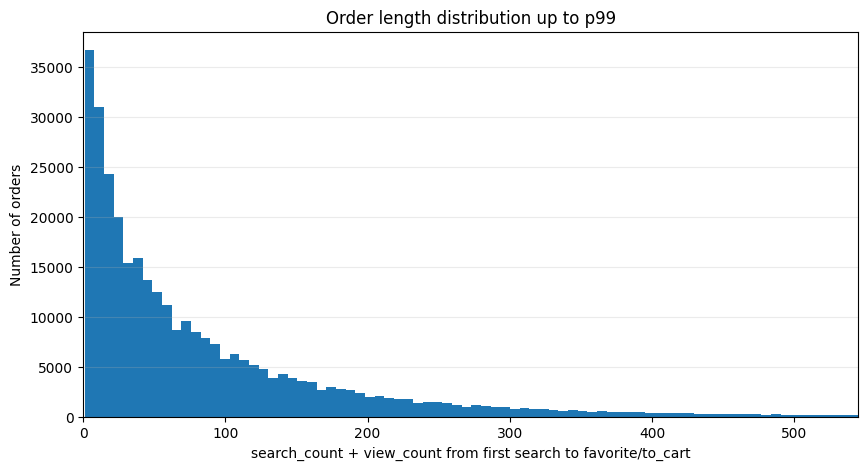

In [33]:
import matplotlib.pyplot as plt

order_lengths = payment_counts.with_columns(
    (pl.col('search_count') + pl.col('view_count')).alias('order_length')
)

display(
    order_lengths
    .select('order_length')
    .describe(percentiles=[0.5, 0.75, 0.9, 0.95, 0.99])
)

p99 = order_lengths.select(pl.col('order_length').quantile(0.99)).item()
lengths = (
    order_lengths
    .filter(pl.col('order_length') <= p99)
    .get_column('order_length')
    .to_numpy()
)

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=80)
plt.title('Order length distribution up to p99')
plt.xlabel('search_count + view_count from first search to favorite/to_cart')
plt.ylabel('Number of orders')
plt.xlim(0, p99)
plt.grid(axis='y', alpha=0.25)
plt.show()

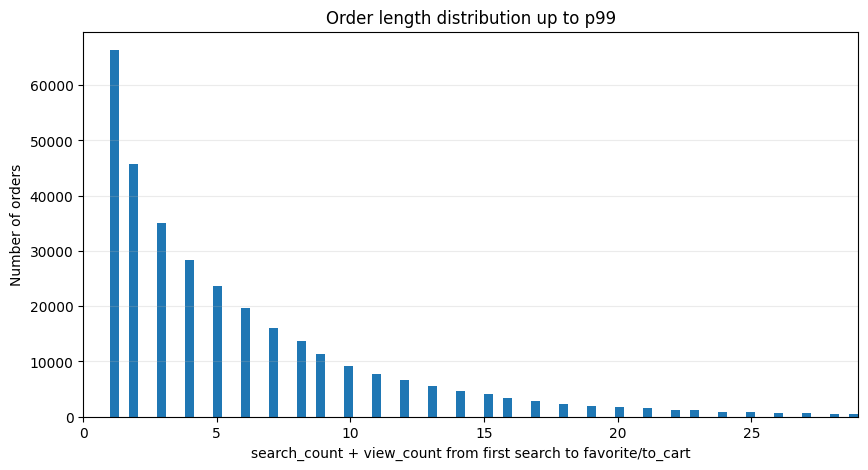

In [34]:
p99 = order_lengths.select(pl.col('search_count').quantile(0.99)).item()
lengths = (
    order_lengths
    .filter(pl.col('search_count') <= p99)
    .get_column('search_count')
    .to_numpy()
)

plt.figure(figsize=(10, 5))
plt.hist(lengths, bins=80)
plt.title('Order length distribution up to p99')
plt.xlabel('search_count + view_count from first search to favorite/to_cart')
plt.ylabel('Number of orders')
plt.xlim(0, p99)
plt.grid(axis='y', alpha=0.25)
plt.show()

In [35]:
min_search_count = 400

search_queries_by_count = (
    s.filter(
        (pl.col('action_type') == 'search')
        & pl.col('search_query').is_not_null()
    )
    .group_by('search_query')
    .len(name='order_length')
    .filter(pl.col('order_length') >= min_search_count)
    .sort('order_length', descending=True)
)

search_queries_by_count

search_query,order_length
str,u32
"""молоко""",5971
"""хлеб""",4589
"""сыр""",4158
"""яйца""",2880
"""сметана""",2635
…,…
"""картошка свежая""",412
"""орехи""",406
"""кофе в зернах""",405


In [36]:
q = search_queries_by_count.filter((pl.col('order_length') >= 2000)).head(50)

In [44]:
w = list(q.get_column('search_query'))
for i in range(10):
    print(w[i])

молоко
хлеб
сыр
яйца
сметана
творог
мороженое
чипсы
вода
туалетная бумага


In [41]:
for i in range(20, len(w)):
    print(w[i])